### <center> Fitting Models to Real Data </center>

Now we will consider fitting a simple SIR model to a real infection curve using the techniques learned in the previous day's materials. First, let's import some real data from a csv and design our model. 

## Workshop Pacing

Day 3 is designed as short cycles:

1. Instructor explains the goal of one step.
2. Participants run the code.
3. Participants change one number or one graph.
4. The group discusses interpretation and classroom use.

The coding level varies, so the exercises emphasize **where to edit**, **what changed**, and **what the graph means**.

The following code cell will extract the CSV containing the CDC's 2023-2024 influenza data. This dataset lists the total number of hospitalizations in Arizona for each day between 10/01/2023 and 04/27/2024. 

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

possible_paths = [Path("AZ_DATA.csv"), Path("../AZ_DATA.csv")]
data_path = next((p for p in possible_paths if p.exists()), None)

if data_path is not None:
    data = pd.read_csv(data_path)
else:
    # Synthetic fallback with the same column name used below.
    rng = np.random.default_rng(seed=2026)
    days = np.arange(210)
    dates = pd.date_range("2023-10-01", periods=len(days), freq="D")
    wave = 20 + 260 * np.exp(-((days - 95) / 38) ** 2)
    hosp = rng.poisson(wave).astype(int)
    data = pd.DataFrame({
        "date": dates.strftime("%Y-%m-%d"),
        "total_patients_hospitalized_confirmed_influenza": hosp
    })
    print("AZ_DATA.csv not found, so a synthetic Arizona-like hospitalization dataset was generated.")

data.head()

,state,date,total_patients_hospitalized_confirmed_influenza
0,AZ,2023-10-01,14.0
1,AZ,2023-10-02,9.0
2,AZ,2023-10-03,6.0
3,AZ,2023-10-04,6.0
4,AZ,2023-10-05,6.0


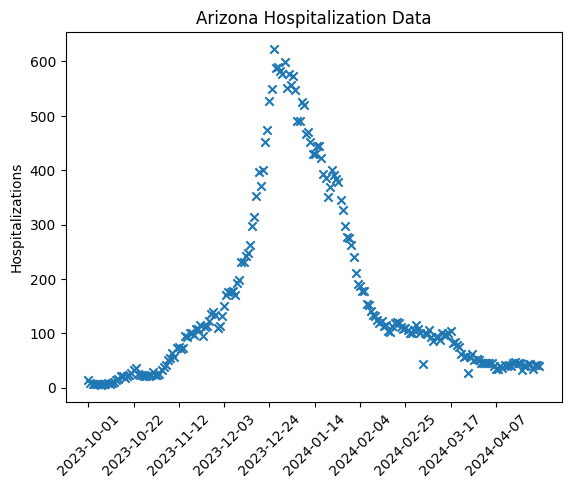

In [2]:
import matplotlib.pyplot as plt
import numpy as np

data_numpy = data['total_patients_hospitalized_confirmed_influenza'].to_numpy()

t_range = np.arange(0,len(data['date']),21)

plt.title('Arizona Hospitalization Data')
plt.ylabel('Hospitalizations')
plt.xticks(ticks = t_range, labels = data['date'].iloc[t_range], rotation=45) 
plt.scatter(np.arange(len(data['date'])),data_numpy, marker = 'x')
plt.show()

### Visualization Pause: Looking at Real Data Before Modeling

Before fitting a model, ask participants what the data shows.

**Core:** Identify the peak and describe the overall pattern.

**Stretch:** Compare daily data to a rolling average.

Peak date: 2023-12-26
Peak hospitalizations: 623


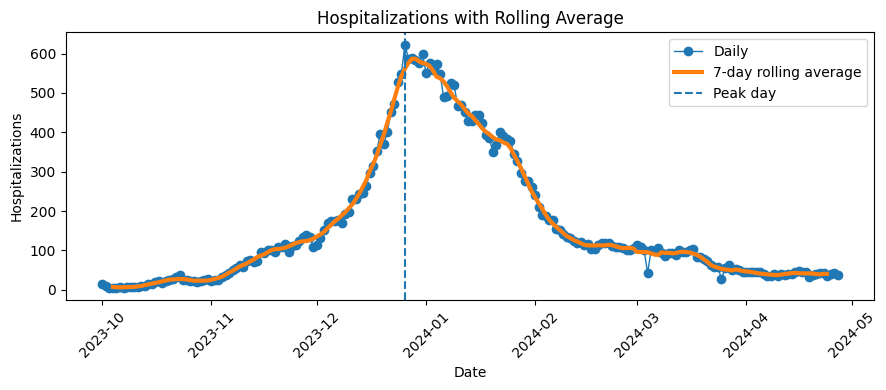

In [3]:
data_viz = data.copy()
data_viz["date"] = pd.to_datetime(data_viz["date"])
data_viz["hospitalized"] = data_viz["total_patients_hospitalized_confirmed_influenza"]
data_viz["rolling_7"] = data_viz["hospitalized"].rolling(window=7, center=True).mean()

peak_row = data_viz.loc[data_viz["hospitalized"].idxmax()]
print("Peak date:", peak_row["date"].date())
print("Peak hospitalizations:", int(peak_row["hospitalized"]))

plt.figure(figsize=(9, 4))
plt.plot(data_viz["date"], data_viz["hospitalized"], marker="o", linewidth=1, label="Daily")
plt.plot(data_viz["date"], data_viz["rolling_7"], linewidth=3, label="7-day rolling average")
plt.axvline(peak_row["date"], linestyle="--", label="Peak day")
plt.title("Hospitalizations with Rolling Average")
plt.xlabel("Date")
plt.ylabel("Hospitalizations")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Exercise 1: Data Story

Write two sentences:

1. What pattern do you see?
2. What might make the real data different from a simple SIR model?

We can see that over the course of the year, Arizona's hospitalizations followed a curve similar to our SIR model experiments. There are clear deviations, but the pattern of exponential growth and exponential decay is present. 

To incorporate this data into our model we need to make a small modification. Note the structure of the SIR model, 

$$
\begin{align*}
\frac{dS}{dt} &= -\frac{\beta S I}{N} \\
\frac{dI}{dt} &= \frac{\beta S I}{N} - \gamma I \\
\frac{dR}{dt} &= \gamma I. \\
\end{align*}
$$

We have compartments corresponding to Susceptible, Infected, and Recovered but our data is actually the number of people hospitalized. There are two common approaches to incorporating hospitalization into SIR type models. The first is to develop an SIRH model, which we discussed in the Day 2 notebook. The second approach, which we will take here is to assume a proportion of the infected compartment is hospitalized at any time. Then we introduce the scale parameter $\rho$ to account for hospitalization. The full model is the SIR model together with

\begin{align*}
H = \rho I. 
\end{align*}

Our model now three parameters to identify from the data, $\beta$, $\gamma$, and $\rho$. Additionally, the number of infected individuals at time 0 is unknown and serves as another free parameter in the model. 

Let's now develop the loss function based on our discussion in the Day 2 notebook. We can express the loss function as follows

$$
\begin{align*}
\mathcal{L}(\beta,\gamma, \rho, I_{0}) = \sum\limits_{n=1}^{N}(x_{n} - \rho I(t_n;\beta,\gamma,I_{0}))^2
\end{align*}
$$

Where $n = 1,\dots,N$ enumerates each day of real data. To simplify the estimation problem we will fix $I_{0}$ and $\rho$ to values obtained from numerical optimization, so we can perform a grid search over the loss function as in the previous notebook. 

Let $\rho = 0.0014$ and $I_{0} = 3040$. The following code cell defines the model and the loss function.

In [4]:
def sir_rhs(X, params):
    S, I, R = X
    N = S + I + R
    beta, gamma = params
    dS = -beta * S * I / N
    dI = beta * S * I / N - gamma * I
    dR = gamma * I
    return np.array([dS, dI, dR])


def model(rhs, x0, ts, par):
    delta_t = ts[1] - ts[0]
    xs = np.zeros((len(ts), len(x0)))
    xs[0, :] = x0

    for t_index in range(1, len(ts)):
        x_prev = xs[t_index - 1]
        xs[t_index] = x_prev + delta_t * rhs(x_prev, par)

    return xs


def loss(par_prop, data):
    rho = 0.0014
    x0 = np.array([7_600_000.0, 3040.0, 0.0])
    delta_t = 0.1
    ts = np.arange(0, len(data), delta_t)
    sol_prop = model(sir_rhs, x0, ts, par_prop)
    return np.sum((data - rho * sol_prop[:: int(1 / delta_t), 1]) ** 2)


loss((0.3, 0.1), data_numpy)

np.float64(199386421.3734857)

Now we can perform the grid search and visualize our results. 

In [5]:
spacing = 0.02
param_range = np.arange(0, 0.5 + spacing, spacing)

B, G = np.meshgrid(param_range, param_range)
loss_vals = np.zeros(B.shape)


for i in range(len(param_range)): 
    for j in range(len(param_range)): 
        loss_vals[i, j] = loss((B[i, j], G[i, j]), data_numpy)

flat_index = np.argmin(loss_vals)
row, col = np.unravel_index(flat_index, loss_vals.shape)
best_beta = B[row, col]
best_gamma = G[row, col]
min_loss = loss_vals[row, col]

print(f"Minimum occurs at: β={best_beta:.4f}, γ={best_gamma:.4f} with value {min_loss:.4f}")

Minimum occurs at: β=0.2200, γ=0.1600 with value 906871.4024


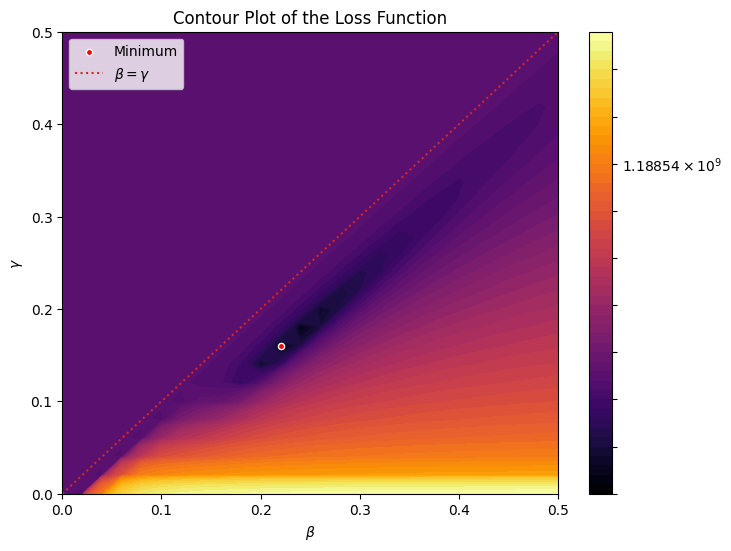

In [6]:
from matplotlib.colors import LogNorm
plt.figure(figsize=(8, 6))

plt.contourf(B, G, loss_vals, levels=np.logspace(np.log10(loss_vals.min()), 
                                               np.log10(loss_vals.max()), 50), 
             norm=LogNorm(), cmap='inferno')

plt.colorbar()
plt.scatter(best_beta, best_gamma, color='red', edgecolors='white', s=20, label='Minimum', zorder=100)

plt.title("Contour Plot of the Loss Function")
plt.plot(param_range,param_range,color = 'tab:red',ls = 'dotted',label = "$\\beta = \\gamma$")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\gamma$")
plt.legend()
plt.show()

### Exercise 2: Loss Surface Interpretation

**Core:** Find the best `beta` and `gamma` printed above. What does each parameter mean?

**Stretch:** Look at the contour plot. Are there nearby parameter values with similar loss?

**Teaching note:** This is a good place to discuss that fitting a model does not mean the model is “true.”

In [7]:
# Optional: create a table of the ten best grid-search parameter pairs.
flat_order = np.argsort(loss_vals.ravel())[:10]
best_rows = []
for idx in flat_order:
    row, col = np.unravel_index(idx, loss_vals.shape)
    best_rows.append({
        "beta": B[row, col],
        "gamma": G[row, col],
        "loss": loss_vals[row, col]
    })

pd.DataFrame(best_rows)

,beta,gamma,loss
0,0.22,0.16,9.068714e+05
1,0.24,0.18,1.107873e+06
2,0.26,0.20,1.776099e+06
3,0.20,0.14,1.817081e+06
4,0.26,0.18,2.592926e+06
5,0.28,0.22,2.611948e+06
6,0.24,0.16,2.850184e+06
7,0.28,0.20,3.003353e+06
8,0.30,0.24,3.474376e+06
9,0.30,0.22,3.679455e+06


Finally, let's plot the solution of model with the optimal against the real data. 

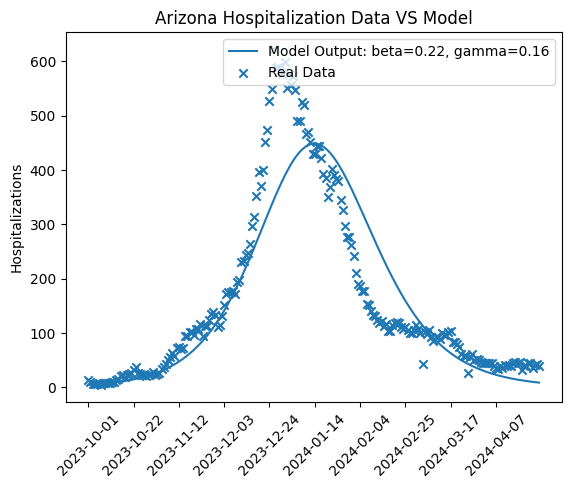

In [8]:
data_numpy = data['total_patients_hospitalized_confirmed_influenza'].to_numpy()

rho = 0.0014
t_range = np.arange(0,len(data['date']),21)
solve_range = np.arange(len(data['date']))

x0 = np.array([7_600_000., 3040.,0.])
model_output = model(sir_rhs, x0, solve_range, (best_beta, best_gamma))

plt.title('Arizona Hospitalization Data VS Model')
plt.ylabel('Hospitalizations')
plt.xticks(ticks = t_range, labels = data['date'].iloc[t_range], rotation=45) 
plt.plot(solve_range, rho * model_output[:, 1], label=f'Model Output: beta={best_beta:.2f}, gamma={best_gamma:.2f}')
plt.scatter(solve_range,data_numpy, marker = 'x', label = 'Real Data')
plt.legend()
plt.show()

## Residual Visualization

A fitted model should be checked, not just plotted. A residual is

$$
\text{residual} = \text{observed} - \text{predicted}.
$$

Residual plots help students see where the model over-predicts or under-predicts.

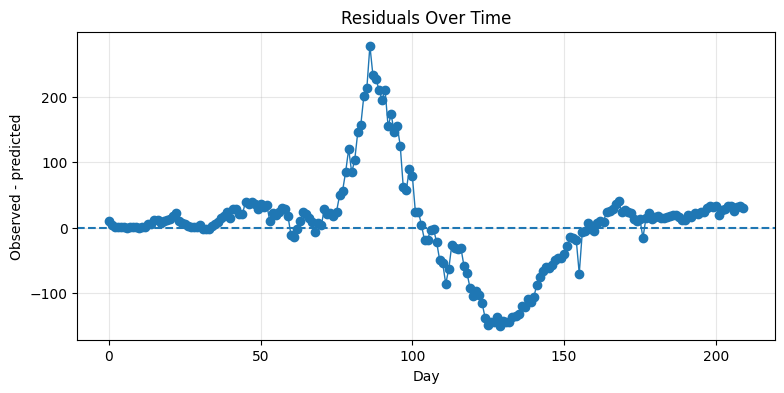

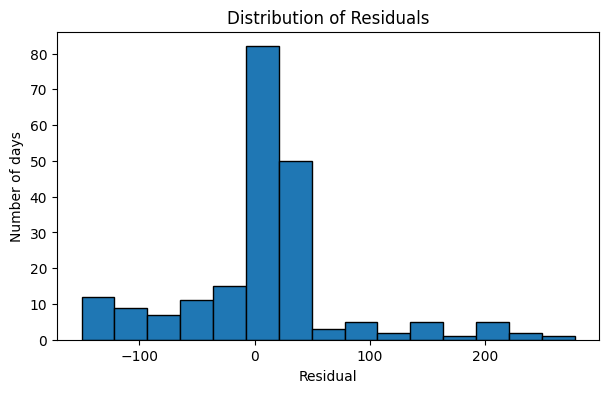

In [9]:
model_pred = rho * model_output[:, 1]
residuals = data_numpy - model_pred

plt.figure(figsize=(9, 4))
plt.axhline(0, linestyle="--")
plt.plot(solve_range, residuals, marker="o", linewidth=1)
plt.title("Residuals Over Time")
plt.xlabel("Day")
plt.ylabel("Observed - predicted")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=15, edgecolor="black")
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Number of days")
plt.show()

### Exercise 3: Model Checking

**Core:** On which part of the season does the model miss the most?

**Stretch:** Change `rho` or the initial infected value `I0` in the earlier model cell and rerun the fit. What changes?

## Optional Inference Extension: A Simple MCMC Sampler

Grid search gives one best point. MCMC gives a cloud of plausible parameter values. This is useful for discussing uncertainty.

To keep the example accessible, we use a simple Metropolis sampler with a loss-based score:

$$
\log p(\beta, \gamma \mid \text{data}) \propto -\frac{\mathcal{L}(\beta,\gamma)}{2\sigma^2}
$$

inside the prior range $0 < \beta < 0.5$ and $0 < \gamma < 0.5$.

In [10]:
def log_posterior(params, data, sigma=40):
    beta, gamma = params
    if beta <= 0 or beta >= 0.5 or gamma <= 0 or gamma >= 0.5:
        return -np.inf
    return -loss((beta, gamma), data) / (2 * sigma**2)


def metropolis_sampler(start, data, n_steps=1500, proposal_scale=0.001, sigma=40, seed=2026):
    rng = np.random.default_rng(seed)
    samples = np.zeros((n_steps, 2))
    samples[0] = np.array(start)
    current_lp = log_posterior(samples[0], data, sigma=sigma)
    accepted = 0

    for k in range(1, n_steps):
        proposal = samples[k - 1] + rng.normal(0, proposal_scale, size=2)
        proposal_lp = log_posterior(proposal, data, sigma=sigma)

        if np.log(rng.uniform()) < proposal_lp - current_lp:
            samples[k] = proposal
            current_lp = proposal_lp
            accepted += 1
        else:
            samples[k] = samples[k - 1]

    return samples, accepted / (n_steps - 1)

samples, acceptance_rate = metropolis_sampler((best_beta, best_gamma), data_numpy, n_steps=800)
print("Acceptance rate:", round(acceptance_rate, 3))
print("Posterior mean beta/gamma:", samples[300:].mean(axis=0))

Acceptance rate: 0.269
Posterior mean beta/gamma: [0.23031816 0.16376713]


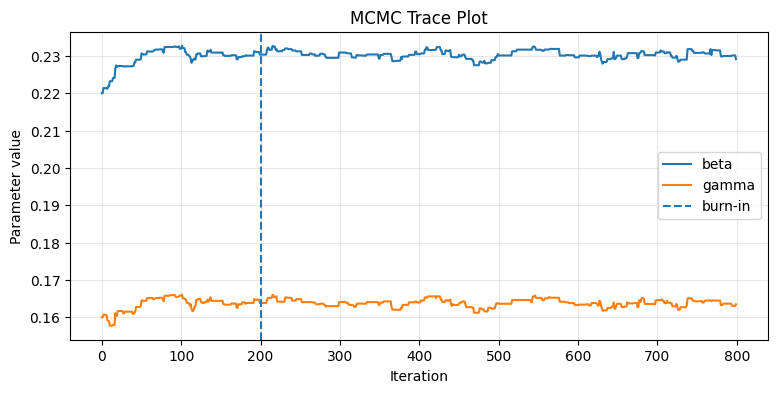

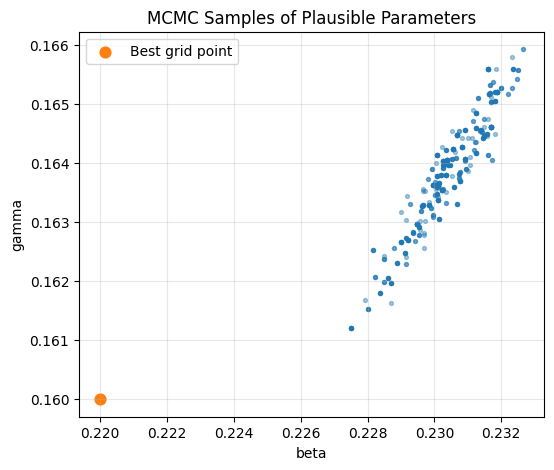

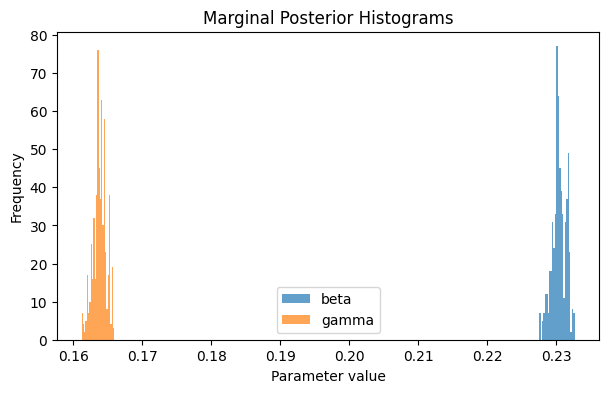

In [11]:
burn = 200
post = samples[burn:]

plt.figure(figsize=(9, 4))
plt.plot(samples[:, 0], label="beta")
plt.plot(samples[:, 1], label="gamma")
plt.axvline(burn, linestyle="--", label="burn-in")
plt.title("MCMC Trace Plot")
plt.xlabel("Iteration")
plt.ylabel("Parameter value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(post[:, 0], post[:, 1], s=8, alpha=0.4)
plt.scatter(best_beta, best_gamma, s=60, label="Best grid point")
plt.xlabel("beta")
plt.ylabel("gamma")
plt.title("MCMC Samples of Plausible Parameters")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(post[:, 0], bins=25, alpha=0.7, label="beta")
plt.hist(post[:, 1], bins=25, alpha=0.7, label="gamma")
plt.title("Marginal Posterior Histograms")
plt.xlabel("Parameter value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Exercise 4: MCMC Exploration

**Core:** Change `proposal_scale` from `0.001` to `0.0005` or `0.005`. What happens to the acceptance rate?

**Stretch:** Change `sigma`. How does the spread of the samples change?

**Classroom connection:** This is an advanced example of uncertainty. For high school students, the key idea can be simplified to “many parameter values may explain the data nearly equally well.”

## Final DataJam / Classroom Connection

In groups, choose one dataset or model from the workshop and prepare a 3-minute classroom adaptation.

Include:

1. The student-facing question.
2. The dataset or simulation.
3. One graph students will create.
4. One sentence students should write to interpret the result.
5. A low-code option for students who need more support.

In [12]:
# Final planning workspace
classroom_plan = pd.DataFrame({
    "Component": ["Student question", "Dataset/model", "Graph", "Interpretation sentence", "Low-code support"],
    "Your plan": ["", "", "", "", ""]
})
classroom_plan

,Component,Your plan
0,Student question,
1,Dataset/model,
2,Graph,
3,Interpretation sentence,
4,Low-code support,
